# EDA

NAB realAWSCloudwatch - утилизация CPU EC2. Три ряда `ec2_cpu_utilization_*`: 5-мин шаг, 14 дней, по 4032 точки. Размеченные окна аномалий - `combined_windows.json`.

In [1]:
# для Colab: раскомментировать при первом запуске
# !pip install -q statsforecast mlforecast neuralforecast utilsforecast holidays stumpy


In [2]:
import sys
import os
from pathlib import Path

# если запускаем из notebooks/, добавляем корень репо в путь
ROOT = Path('.').resolve()
if (ROOT / 'src').exists():
    pass
elif (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print('Working dir:', ROOT)


Working dir: /Users/novikov/src/timeseries_forecast


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

import warnings
warnings.filterwarnings('ignore')

sns.set_style('white')
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


In [4]:
from src.data import (
    download_nab, load_panel, load_anomaly_labels, make_anomaly_mask,
    train_test_split_panel, DAILY_SEASON, WEEKLY_SEASON, FREQ,
)

# скачиваем данные, если их еще нет
download_nab()

panel = load_panel()
windows, points = load_anomaly_labels()

print(f'Форма panel: {panel.shape}')
print(f'Колонки: {list(panel.columns)}')
print(f'Уникальные ряды: {panel["unique_id"].unique().tolist()}')
print(f'Точек на ряд: {panel.groupby("unique_id").size().iloc[0]}')
print(f'Диапазон дат: {panel.ds.min()} - {panel.ds.max()}')
print(f'Частота: {FREQ}, дневная сезонность={DAILY_SEASON}, недельная={WEEKLY_SEASON}')
panel.head(3)


Форма panel: (12093, 3)
Колонки: ['unique_id', 'ds', 'y']
Уникальные ряды: ['ec2_cpu_utilization_24ae8d', 'ec2_cpu_utilization_53ea38', 'ec2_cpu_utilization_5f5533']
Точек на ряд: 4031
Диапазон дат: 2014-02-14 14:30:00 - 2014-02-28 14:20:00
Частота: 5min, дневная сезонность=288, недельная=2016


,unique_id,ds,y
0,ec2_cpu_utilization_24ae8d,2014-02-14 14:30:00,0.132
1,ec2_cpu_utilization_24ae8d,2014-02-14 14:35:00,0.134
2,ec2_cpu_utilization_24ae8d,2014-02-14 14:40:00,0.134


### Качество: пропуски, дубликаты, регулярность

In [5]:
def quality_report(panel):
    rows = []
    for uid, g in panel.groupby('unique_id'):
        g = g.set_index('ds').sort_index()
        diffs = g.index.to_series().diff().dropna().value_counts()
        rows.append({
            'unique_id': uid,
            'n': len(g),
            'monotone': g.index.is_monotonic_increasing,
            'duplicates': int(g.index.duplicated().sum()),
            'missing_y': int(g['y'].isna().sum()),
            'unique_step': len(diffs) == 1,
            'main_step': str(diffs.index[0]),
        })
    return pd.DataFrame(rows)

quality_report(panel)


,unique_id,n,monotone,duplicates,missing_y,unique_step,main_step
0,ec2_cpu_utilization_24ae8d,4031,True,0,0,True,0 days 00:05:00
1,ec2_cpu_utilization_53ea38,4031,True,0,0,True,0 days 00:05:00
2,ec2_cpu_utilization_5f5533,4031,True,0,0,True,0 days 00:05:00


Ряды регулярны (5-мин шаг), без пропусков и дубликатов.

## Визуализация рядов

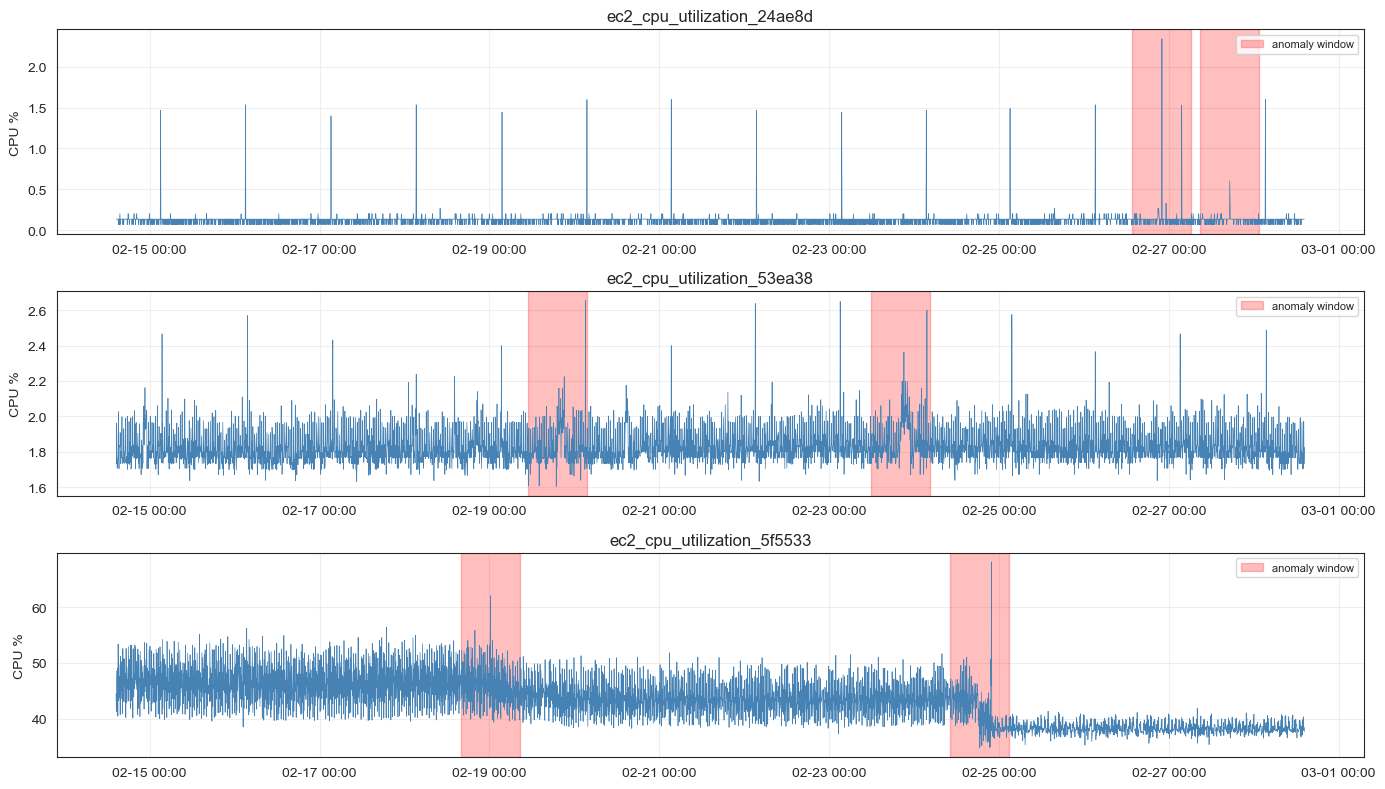

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)
for ax, (uid, g) in zip(axes, panel.groupby('unique_id')):
    ax.plot(g['ds'], g['y'], linewidth=0.5, color='steelblue')
    # Подсветим окна аномалий
    for start, end in windows.get(uid, []):
        ax.axvspan(start, end, color='red', alpha=0.25, label='anomaly window')
    ax.set_title(uid)
    ax.set_ylabel('CPU %')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('report/figures/01_overview.png', dpi=120, bbox_inches='tight')
plt.show()


Видна суточная сезонность. Размеченные окна аномалий попадают на провалы и спайки.

## Распределения и сезонность

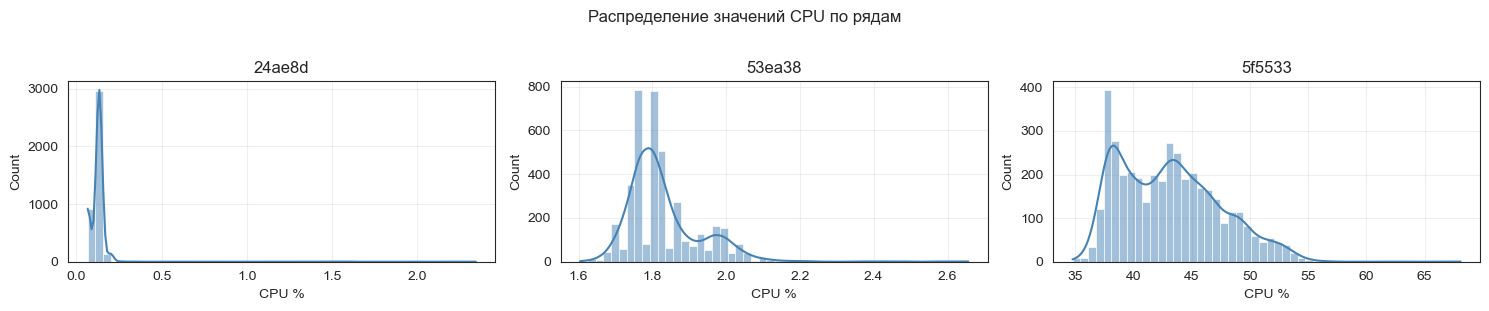

In [7]:
# календарные признаки для группировок
panel_eda = panel.copy()
panel_eda['hour'] = panel_eda['ds'].dt.hour
panel_eda['dow'] = panel_eda['ds'].dt.dayofweek
panel_eda['minute'] = panel_eda['ds'].dt.minute
panel_eda['date'] = panel_eda['ds'].dt.date

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, (uid, g) in zip(axes, panel_eda.groupby('unique_id')):
    sns.histplot(g['y'], kde=True, bins=50, ax=ax, color='steelblue')
    ax.set_title(uid.replace('ec2_cpu_utilization_', ''))
    ax.set_xlabel('CPU %')
plt.suptitle('Распределение значений CPU по рядам', y=1.02)
plt.tight_layout()
plt.savefig('report/figures/01_hist.png', dpi=120, bbox_inches='tight')
plt.show()


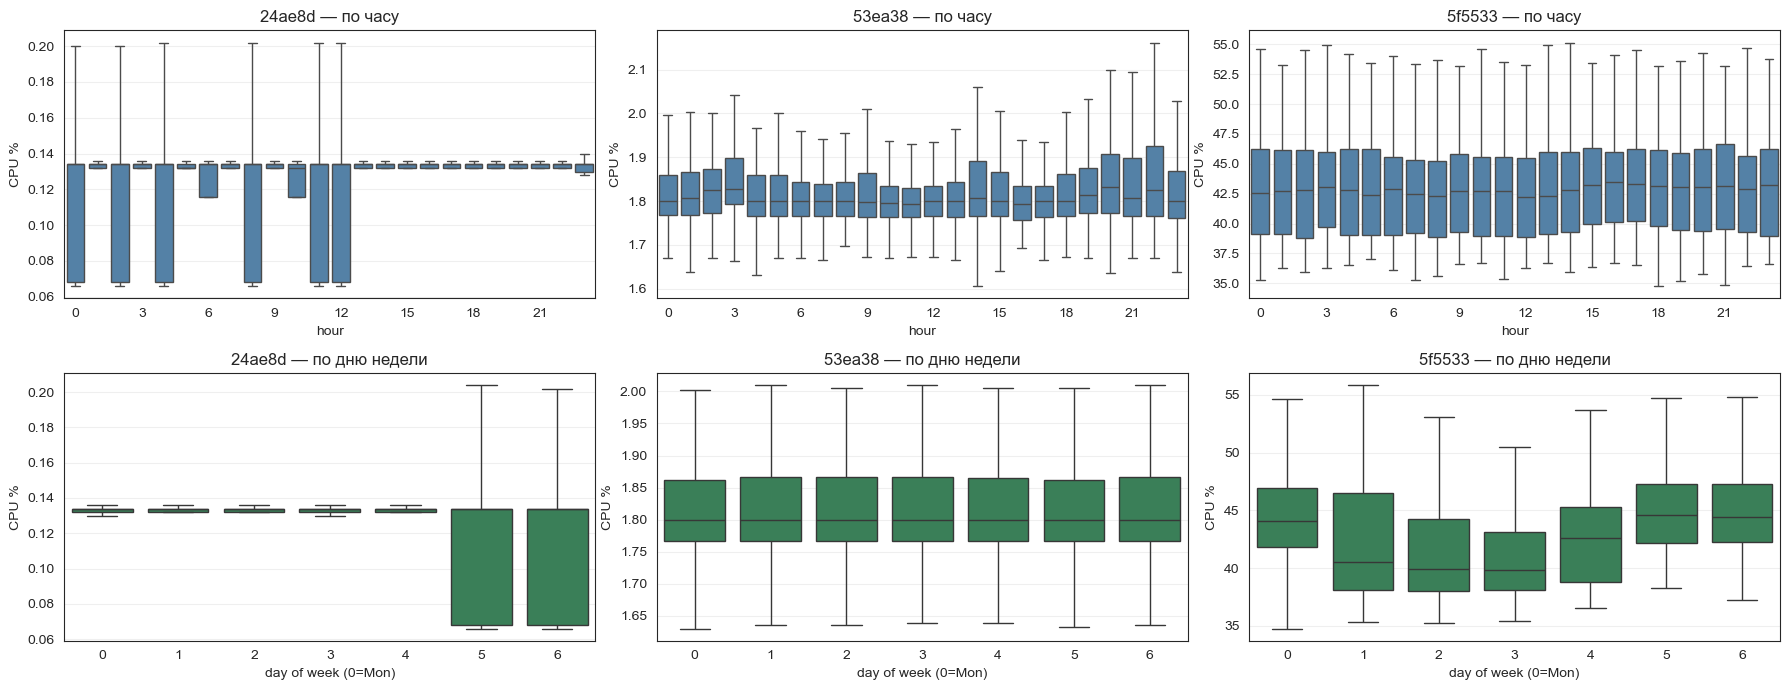

In [8]:
# Boxplot по часу суток и дню недели
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
for col, (uid, g) in enumerate(panel_eda.groupby('unique_id')):
    sns.boxplot(data=g, x='hour', y='y', ax=axes[0, col],
                color='steelblue', showfliers=False)
    axes[0, col].set_title(f'{uid.replace("ec2_cpu_utilization_", "")} - по часу')
    axes[0, col].set_xlabel('hour'); axes[0, col].set_ylabel('CPU %')
    axes[0, col].set_xticks(range(0, 24, 3))

    sns.boxplot(data=g, x='dow', y='y', ax=axes[1, col],
                color='seagreen', showfliers=False)
    axes[1, col].set_title(f'{uid.replace("ec2_cpu_utilization_", "")} - по дню недели')
    axes[1, col].set_xlabel('day of week (0=Mon)'); axes[1, col].set_ylabel('CPU %')
plt.tight_layout()
plt.savefig('report/figures/01_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()


Форма суточного цикла различается по рядам (у одного ночной пик, у других дневной). Недельная структура на 14 днях выражена слабо → в `MSTL` берем `[288, 2016]` с основным периодом 288.

## Декомпозиция STL

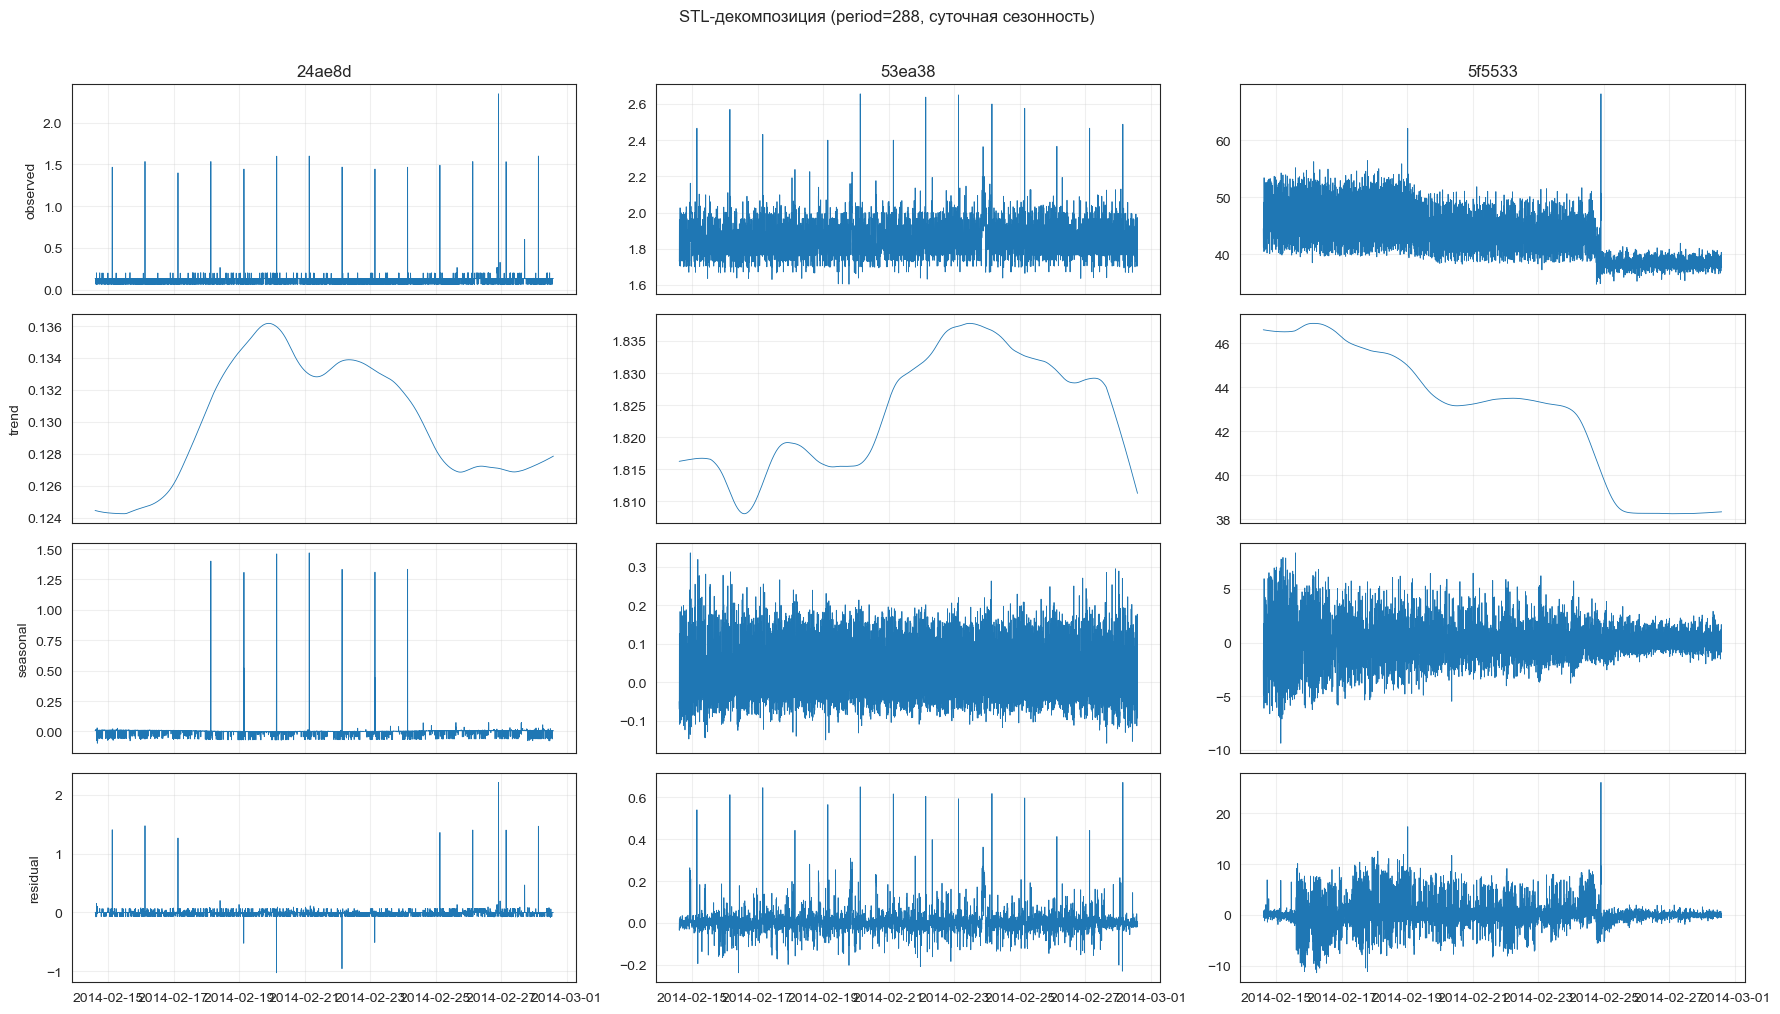

In [9]:
def decompose_one(g, period=DAILY_SEASON):
    y = g.set_index('ds')['y']
    stl = STL(y, period=period, robust=True).fit()
    return stl

fig, axes = plt.subplots(4, 3, figsize=(18, 10), sharex='col')
for col, (uid, g) in enumerate(panel.groupby('unique_id')):
    stl = decompose_one(g, period=DAILY_SEASON)
    for row, (name, comp) in enumerate([
        ('observed', stl.observed),
        ('trend', stl.trend),
        ('seasonal', stl.seasonal),
        ('residual', stl.resid),
    ]):
        axes[row, col].plot(comp.index, comp.values, linewidth=0.6)
        if col == 0:
            axes[row, col].set_ylabel(name)
        if row == 0:
            axes[row, col].set_title(uid.replace('ec2_cpu_utilization_', ''))
plt.suptitle('STL-декомпозиция (period=288, суточная сезонность)', y=1.01)
plt.tight_layout()
plt.savefig('report/figures/01_stl.png', dpi=120, bbox_inches='tight')
plt.show()


Амплитуда суточного цикла стабильная, `period=288` подходит. В остатках - резкие выбросы на размеченных аномалиях.

## Тесты стационарности

In [10]:
def stationarity_tests(y, p_threshold=0.05):
    adf_stat, adf_p, *_ = adfuller(y, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(y, regression='c', nlags='auto')
    return {
        'ADF_stat': adf_stat,
        'ADF_p': adf_p,
        'ADF_stationary': adf_p < p_threshold,
        'KPSS_stat': kpss_stat,
        'KPSS_p': kpss_p,
        'KPSS_stationary': kpss_p >= p_threshold,
    }

rows = []
for uid, g in panel.groupby('unique_id'):
    r = stationarity_tests(g['y'].values)
    r['unique_id'] = uid
    rows.append(r)
stat_df = pd.DataFrame(rows).set_index('unique_id')
stat_df.style.format({c: '{:.4f}' for c in ['ADF_stat','ADF_p','KPSS_stat','KPSS_p']})


,ADF_stat,ADF_p,ADF_stationary,KPSS_stat,KPSS_p,KPSS_stationary
unique_id,,,,,,
ec2_cpu_utilization_24ae8d,-46.9171,0.0000,True,0.2080,0.1000,True
ec2_cpu_utilization_53ea38,-9.8377,0.0000,True,1.2333,0.0100,False
ec2_cpu_utilization_5f5533,-0.7105,0.8440,False,8.8792,0.0100,False


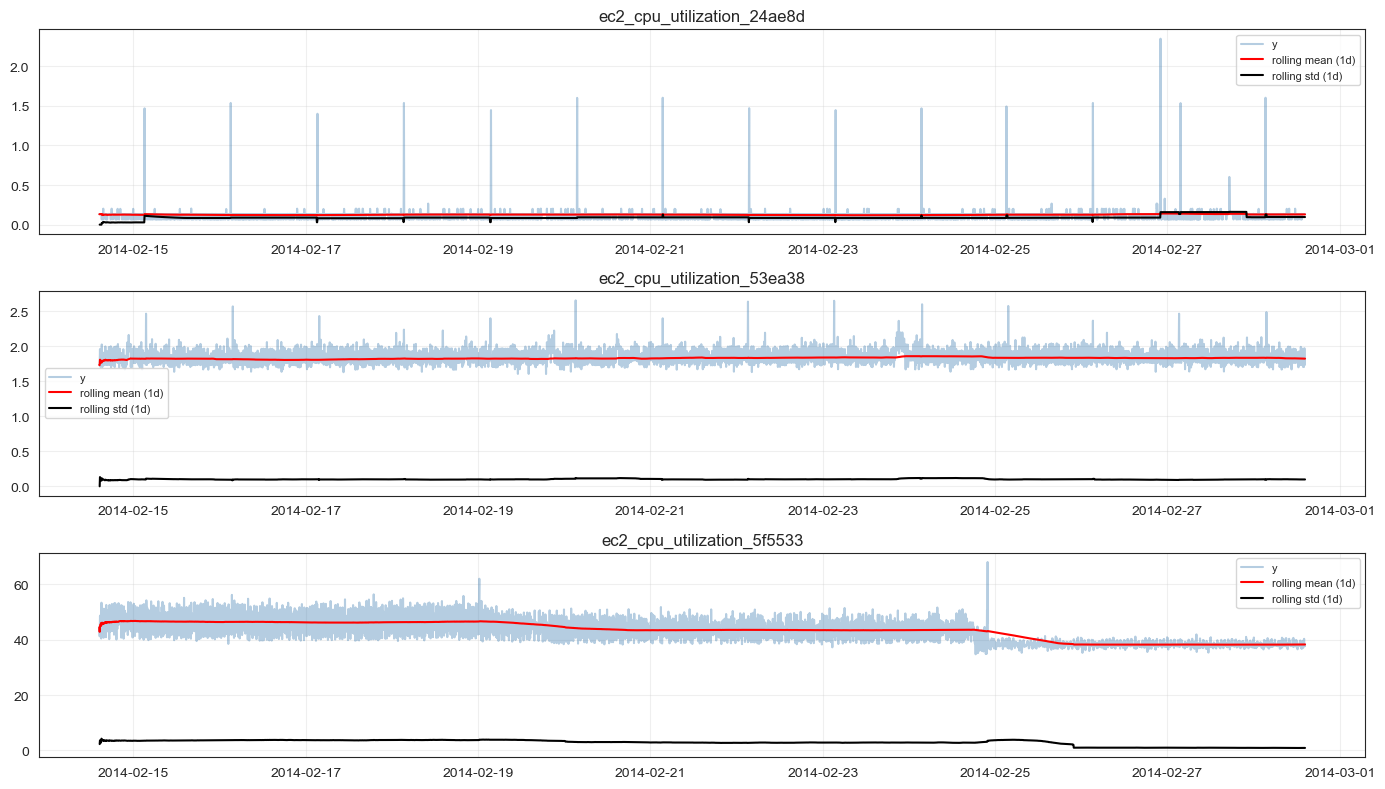

In [11]:
# скользящие mean и std для оценки стационарности
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)
for ax, (uid, g) in zip(axes, panel.groupby('unique_id')):
    y = g.set_index('ds')['y']
    rmean = y.rolling(DAILY_SEASON, min_periods=1).mean()
    rstd = y.rolling(DAILY_SEASON, min_periods=1).std()
    ax.plot(y.index, y.values, color='steelblue', alpha=0.4, label='y')
    ax.plot(rmean.index, rmean.values, color='red', label='rolling mean (1d)')
    ax.plot(rstd.index, rstd.values, color='black', label='rolling std (1d)')
    ax.set_title(uid)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('report/figures/01_rolling.png', dpi=120, bbox_inches='tight')
plt.show()


## ACF и PACF

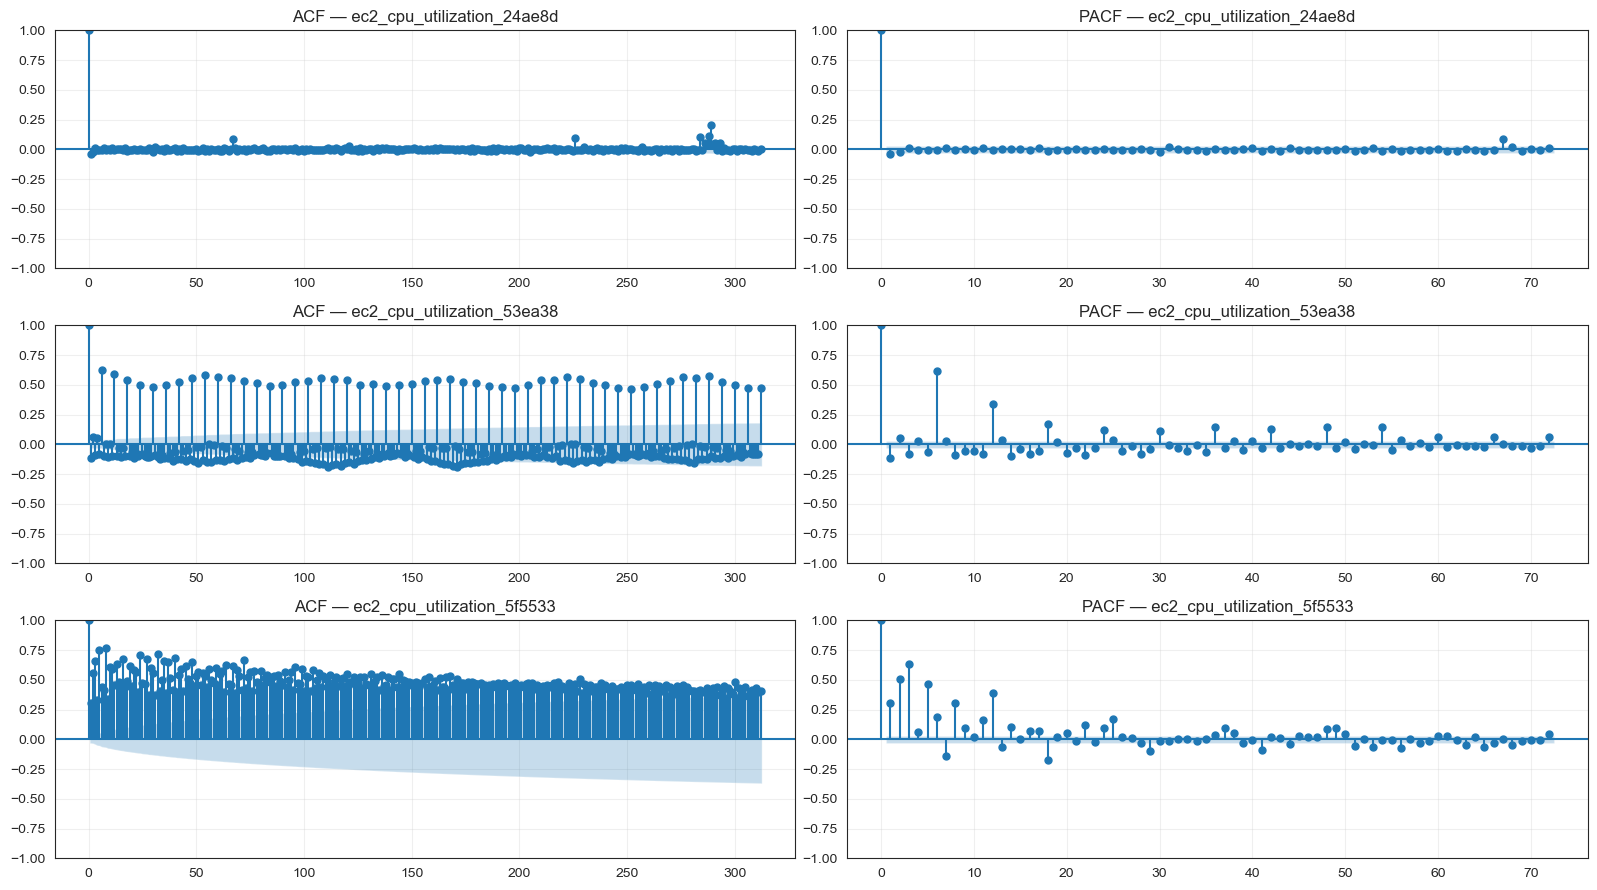

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16, 9))
for row, (uid, g) in enumerate(panel.groupby('unique_id')):
    y = g['y'].values
    plot_acf(y, lags=DAILY_SEASON + 24, ax=axes[row, 0], title=f'ACF - {uid}')
    plot_pacf(y, lags=72, method='ywm', ax=axes[row, 1], title=f'PACF - {uid}')
plt.tight_layout()
plt.savefig('report/figures/01_acf_pacf.png', dpi=120, bbox_inches='tight')
plt.show()


ACF: всплеск на лаге 288 (суточная сезонность). PACF: 2-4 значимых лага → небольшой AR-порядок.

## Связи между рядами

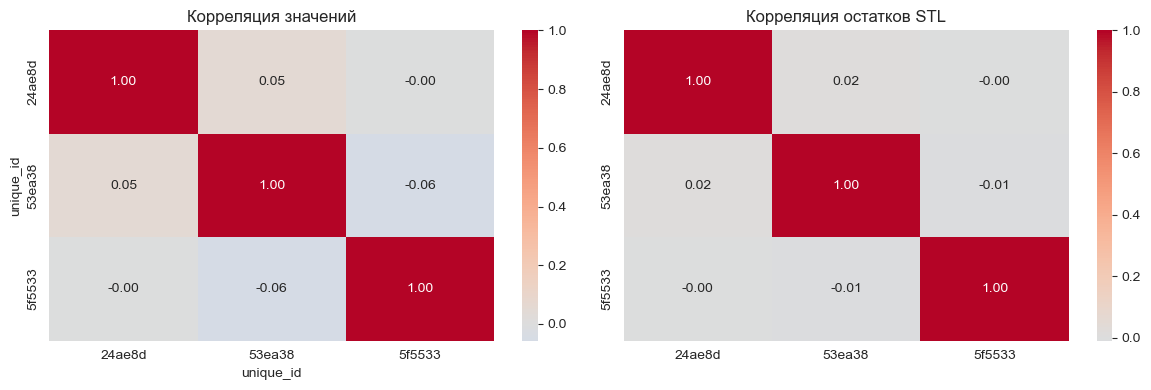

In [13]:
# корреляции между рядами: по значениям и по STL-остаткам
pivot = panel.pivot(index='ds', columns='unique_id', values='y')
short_names = {c: c.replace('ec2_cpu_utilization_', '') for c in pivot.columns}
pivot = pivot.rename(columns=short_names)

resids = pd.DataFrame(index=pivot.index)
for uid, col in zip(panel['unique_id'].unique(), pivot.columns):
    g = panel[panel['unique_id']==uid]
    stl = STL(g.set_index('ds')['y'], period=DAILY_SEASON, robust=True).fit()
    resids[col] = stl.resid.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(pivot.corr(), annot=True, cmap='coolwarm', center=0, ax=axes[0], fmt='.2f')
axes[0].set_title('Корреляция значений')
sns.heatmap(resids.corr(), annot=True, cmap='coolwarm', center=0, ax=axes[1], fmt='.2f')
axes[1].set_title('Корреляция остатков STL')
plt.tight_layout()
plt.savefig('report/figures/01_corr.png', dpi=120, bbox_inches='tight')
plt.show()


Связи между рядами слабые (~0-0.2 по значениям и остаткам) → моделируем независимо, но держим в едином panel для глобальных ML/DL.

## Train / Test split + аномалии

In [14]:
df_train, df_test, FH = train_test_split_panel(panel, fh_frac=0.42)
print(f'FH={FH} шагов (~{FH/DAILY_SEASON:.2f} суток)')
print(f'Train rows: {len(df_train)}, Test rows: {len(df_test)}')

# Сколько размеченных аномалий попадает в test-окно
anom_mask = make_anomaly_mask(panel, windows).astype(bool)
panel_marked = panel.assign(is_anomaly=anom_mask)
test_marked = panel_marked.merge(
    df_test[['unique_id','ds']].assign(_in_test=True),
    on=['unique_id','ds'], how='left'
).fillna({'_in_test': False})
test_anom = test_marked[test_marked['_in_test']==True].groupby('unique_id')['is_anomaly'].sum()
print()
print('Аномалий в тесте по рядам:')
print(test_anom.to_dict())


FH=1693 шагов (~5.88 суток)
Train rows: 7014, Test rows: 5079

Аномалий в тесте по рядам:
{'ec2_cpu_utilization_24ae8d': 402, 'ec2_cpu_utilization_53ea38': 201, 'ec2_cpu_utilization_5f5533': 200}


Горизонт `h=288` (1 сутки): на 14-дневной истории прогноз на 6+ суток нереалистичен. Для stats - backtest через `cross_validation` с шагом `h`.

In [15]:
out_path = Path('data/processed')
out_path.mkdir(parents=True, exist_ok=True)

panel_marked.to_parquet(out_path / 'nab_panel.parquet', index=False)
print(f'Saved: {out_path / "nab_panel.parquet"} ({len(panel_marked)} rows)')

# сохраняем мету (FH, сезонности) рядом с panel
import json
meta = {
    'freq': FREQ,
    'daily_season': DAILY_SEASON,
    'weekly_season': WEEKLY_SEASON,
    'fh': FH,
    'fh_frac': 0.42,
    'series': panel['unique_id'].unique().tolist(),
}
with open(out_path / 'meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('Meta saved.')


Saved: data/processed/nab_panel.parquet (12093 rows)
Meta saved.
